Blacklisting

In [ ]:
import pandas as pd
from urllib.parse import urlparse

class BlacklistChecker:
    def __init__(self, blacklist_path="blacklist_dataset_cleaned (2).csv"):
        """
        Load the dataset and initialize blacklist sets.
        """
        self.df = pd.read_csv(blacklist_path)
        # ensure required columns exist
        if "url" not in self.df.columns or "label" not in self.df.columns:
            raise ValueError("CSV must contain 'url' and 'label' columns.")

        # Normalize URLs in dataset
        self.df["url_clean"] = self.df["url"].astype(str).str.strip().str.rstrip("/")

        # Prepare sets for faster matching
        self.blacklist_full = set()     # Full url match
        self.blacklist_no_scheme = set() # match without scheme (http/https)

        # extract phishing urls
        phishing_urls = self.df[self.df["label"] == 1]["url_clean"].tolist()

        for url in phishing_urls:
          # Add full url to set
            self.blacklist_full.add(url)
            # remove scheme
            no_scheme = url.replace("https://", "").replace("http://", "")
            self.blacklist_no_scheme.add(no_scheme)

      # for input url
    def normalize_url(self, url):
        clean = url.strip().rstrip("/")
        no_scheme = clean.replace("https://", "").replace("http://", "")
        return clean, no_scheme

   # return true if url in blacklist
    def is_blacklisted(self, url):
        clean, no_scheme = self.normalize_url(url)


        return (
            clean in self.blacklist_full or
            no_scheme in self.blacklist_no_scheme

        )






In [ ]:
# -------------------- Test Function -------------------- #
def test_urls(checker, test_list):
    """
    Test multiple URLs and print results.
    """
    print("===== TEST RESULTS =====\n")
    for url in test_list:
       # result = checker.check_url(url)
        result=checker.is_blacklisted(url)
        print(f"URL: {url}")
        #print(f"Blacklist Result: {result['prediction']}")
        print("Blacklist Result:", "Phishing" if result else "Safe or not found")



# -------------------- Example Usage -------------------- #
# Initialize the checker
checker = BlacklistChecker("blacklist_dataset_cleaned (2).csv")

# List of URLs to test
test_list = [
    "http://example-phishingsite.com/login",
    "nobell.it/70ffb52d079109dca5664cce6f317373782/login.skype.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526",
    "https://www.google.com/",
    "mail.printakid.com/www.online.americanexpress.com/index.html",
]

# Run tests
test_urls(checker, test_list)

===== TEST RESULTS =====

URL: http://example-phishingsite.com/login
Blacklist Result: Safe or not found
URL: nobell.it/70ffb52d079109dca5664cce6f317373782/login.skype.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526
Blacklist Result: Safe or not found
URL: https://www.google.com/
Blacklist Result: Safe or not found
URL: mail.printakid.com/www.online.americanexpress.com/index.html
Blacklist Result: Phishing


Heuristic based approach

In [ ]:
from urllib.parse import urlparse
import re     #regular expression for pattern matching
import math

# -------------------- Feature / Heuristic Functions --------------------
def has_ip(url):
    hostname = urlparse(url).netloc
    # Remove port if exists
    hostname = hostname.split(':')[0]
    ipv4 = r"^\d{1,3}(\.\d{1,3}){3}$"
    ipv6 = r"^\[?[0-9a-fA-F:]+\]?$"
    return int(bool(re.match(ipv4, hostname)) or bool(re.match(ipv6, hostname)))


def suspicious_file_extension(url):
  # check for exe or dangerous file
    suspicious = ['.exe', '.zip', '.rar', '.scr', '.php', '.js', '.bat']
    return int(any(url.endswith(ext) for ext in suspicious))

def contains_at_symbol(url):
    return int('@' in url)

def has_hyphen_in_domain(url):
    """Return 1 if domain has 3 or more hyphens, else 0"""
    domain = urlparse(url).netloc
    return int(domain.count('-') >= 3)

def number_of_digits(url):
    return sum(c.isdigit() for c in url)

def url_length(url):
    return len(url)
# too many dots can idnicate subdomain trickery
def dot_count(url):
    return url.count('.')

def subdomain_count(url):
    return urlparse(url).netloc.count('.')

def https_flag(url):
    return int(url.startswith("https://"))

def query_param_count(url):
    parsed = urlparse(url)
    return len(parsed.query.split('&')) if parsed.query else 0

def path_length(url):
    return len(urlparse(url).path)

def url_entropy(url):
  # shanon entropy high means-->random or obfuscated
    prob = [float(url.count(c)) / len(url) for c in set(url)]
    return - sum([p * math.log2(p) for p in prob])

def slash_count(url):
    return url.count('/')

def contains_special_chars(url):
    special_chars = ['_', ',', ';']
    return int(any(char in url for char in special_chars))

# -------------------- Advanced Heuristic --------------------
def advanced_heuristic(url):
    """Phishing detection using important + other features"""
    important_flags = [
        has_ip(url),
        suspicious_file_extension(url),
        contains_at_symbol(url),
        has_hyphen_in_domain(url),
        number_of_digits(url) > 15
    ]

    # If 1 or more important features trigger → phishing
    if sum(important_flags) >= 1:
        return True

    # Non-important features
    other_flags = [
        url_length(url) > 75,
        dot_count(url) > 5,
        subdomain_count(url) > 3,
        https_flag(url) == 0,
        query_param_count(url) > 3,
        path_length(url) > 50,
        url_entropy(url) > 4.5,
        slash_count(url) > 5,
        contains_special_chars(url)
    ]

    # If all non-important features trigger → phishing
    if all(other_flags):
        return True

    return False  # safe

Testing of heuristic based

In [ ]:
test_urls_heuristic = [
    "http://59.99.222.78:55671/i",
    "https://raw.githubusercontent.com/mae-luadev/mae-tests/main/Office.exe",
    "https://www.google.com/",
    "https://metamsk01lgiix.godaddysites.com/",
    "signin.eby.de.zukruygxctzmmqi.civpro.co.za",
    "192.com/atoz/people/oakley/patrick/",
    "https://www.casio.com.cn"
]

for url in test_urls_heuristic:
    result = "Phishing" if advanced_heuristic(url) else "Safe"
    print(f"URL: {url}\nHeuristic Result: {result}\n")


URL: http://59.99.222.78:55671/i
Heuristic Result: Phishing

URL: https://raw.githubusercontent.com/mae-luadev/mae-tests/main/Office.exe
Heuristic Result: Phishing

URL: https://www.google.com/
Heuristic Result: Safe

URL: https://metamsk01lgiix.godaddysites.com/
Heuristic Result: Safe

URL: signin.eby.de.zukruygxctzmmqi.civpro.co.za
Heuristic Result: Safe

URL: 192.com/atoz/people/oakley/patrick/
Heuristic Result: Safe

URL: https://www.casio.com.cn
Heuristic Result: Safe



PHISHING URL DETECTION ML PIPELINE

In [ ]:
import pandas as pd
import numpy as np
import re
import math
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import joblib  # For saving/loading model
import matplotlib.pyplot as plt
import seaborn as sns

Feature Extraction of User url

In [ ]:
def extract_features_for_ml(url):
    """Extract features from URL matching legitphish dataset"""
    def url_length(url): return len(url)
    def has_ip_address(url):
        hostname = urlparse(url).netloc
        ipv4 = r"^\d{1,3}(\.\d{1,3}){3}$"
        ipv6 = r"^\[?[0-9a-fA-F:]+\]?$"
        return int(bool(re.match(ipv4, hostname)) or bool(re.match(ipv6, hostname)))
    def dot_count(url): return url.count('.')
    def https_flag(url): return int(url.startswith("https://"))
    def token_count(url): return len(urlparse(url).path.split('/')) + len(urlparse(url).query.split('&')) if urlparse(url).query else len(urlparse(url).path.split('/'))
    def subdomain_count(url): return urlparse(url).netloc.count('.')
    def query_param_count(url): return len(urlparse(url).query.split('&')) if urlparse(url).query else 0
    def tld_length(url): return len(urlparse(url).netloc.split('.')[-1])
    def path_length(url): return len(urlparse(url).path)
    def has_hyphen_in_domain(url): return int('-' in urlparse(url).netloc)
    def number_of_digits(url): return sum(c.isdigit() for c in url)
    def tld_popularity(url): return 0  # Placeholder
    def suspicious_file_extension(url):
        suspicious = ['.exe', '.zip', '.rar', '.scr', '.php', '.js', '.bat']
        return int(any(url.endswith(ext) for ext in suspicious))
    def domain_name_length(url): return len(urlparse(url).netloc)
    def url_entropy(url):
        prob = [float(url.count(c)) / len(url) for c in set(url)]
        return - sum([p * math.log2(p) for p in prob])
    def percentage_numeric_chars(url): return sum(c.isdigit() for c in url) / len(url) * 100

    features = [
        url_length(url),
        has_ip_address(url),
        dot_count(url),
        https_flag(url),
        url_entropy(url),
        token_count(url),
        subdomain_count(url),
        query_param_count(url),
        tld_length(url),
        path_length(url),
        has_hyphen_in_domain(url),
        number_of_digits(url),
        tld_popularity(url),
        suspicious_file_extension(url),
        domain_name_length(url),
        percentage_numeric_chars(url)
    ]
    return features

Ml Model Traning and Dataset

In [ ]:
# ========================
# 2. LOAD DATASET
# ========================
df = pd.read_csv("processed_scam_url_dataset (1).csv")  # Your CSV
print("Dataset loaded:", df.shape)


Dataset loaded: (100872, 17)


In [ ]:
# ========================
# 3. FEATURE MATRIX
# ========================
feature_columns = [
    'url_length','has_ip_address','dot_count','https_flag','url_entropy','token_count',
    'subdomain_count','query_param_count','tld_length','path_length','has_hyphen_in_domain',
    'number_of_digits','tld_popularity','suspicious_file_extension','domain_name_length',
    'percentage_numeric_chars'
]

# If your dataset already has numeric features
X = df[feature_columns]
y = df['ClassLabel']

In [ ]:
# ========================
# 4. TRAIN-TEST SPLIT
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [ ]:
import time

# ========================
# 7. RANDOM FOREST MODEL TRAINING
# ========================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# Measure training time
start_train = time.time()
rf_model.fit(X_train, y_train)
end_train = time.time()
training_time = end_train - start_train
print(f"Training Time: {training_time:.4f} seconds")

# ========================
# 8. EVALUATION
# ========================

# Measure prediction/testing time
start_test = time.time()
y_pred = rf_model.predict(X_test)
end_test = time.time()
testing_time = end_test - start_test
print(f"Testing/Prediction Time: {testing_time:.4f} seconds")

# Accuracy and classification report
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=6))


Training Time: 11.6248 seconds
Testing/Prediction Time: 0.1465 seconds

Accuracy: 0.9995043370508054

Classification Report:
               precision    recall  f1-score   support

           0   0.999292  0.999921  0.999606     12699
           1   0.999866  0.998796  0.999331      7476

    accuracy                       0.999504     20175
   macro avg   0.999579  0.999359  0.999469     20175
weighted avg   0.999505  0.999504  0.999504     20175



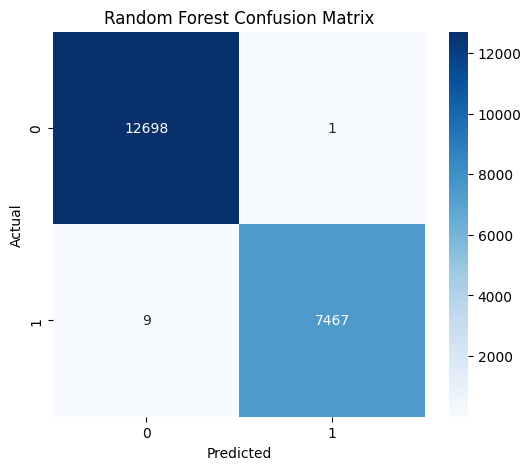

In [ ]:
# ------------------------
# 8a. Confusion Matrix
# ------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()



/tmp/ipython-input-3032034240.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


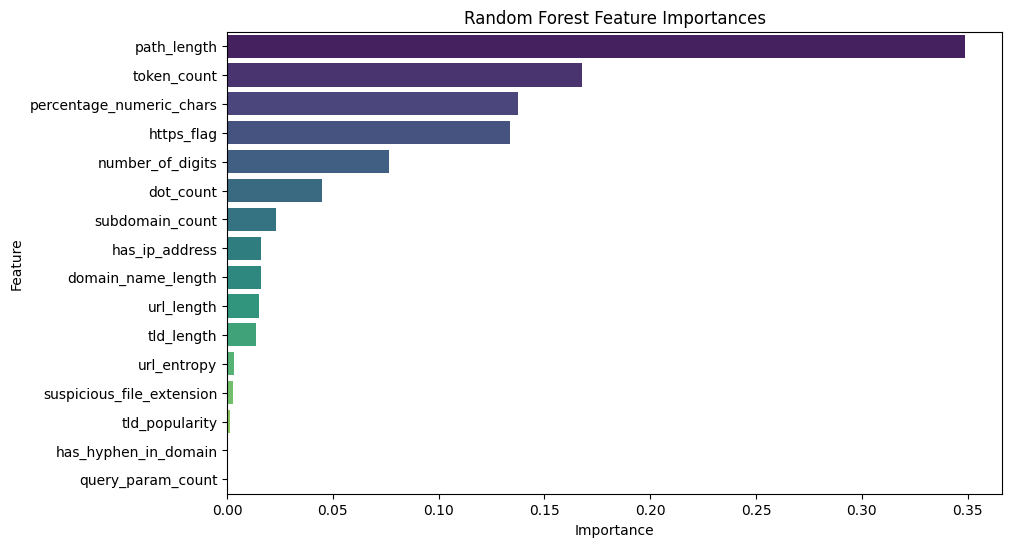

In [ ]:
# ------------------------
# 8b. Feature Importances
# ------------------------
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Random Forest Feature Importances")
plt.show()



In [ ]:


# ========================
# 9. SAVE MODEL & SCALER
# ========================
joblib.dump(rf_model, "rf_phishing_model.pkl")
print("Model and scaler saved for later prediction.")


Model and scaler saved for later prediction.


Cross-validation with 5 folds 4 for traing and 1 for testing

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import joblib

# Load saved Random Forest model
rf_model = joblib.load("rf_phishing_model.pkl")
# Assuming rf_model is already trained
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Average CV score:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))


Cross-validation scores: [0.97814126 0.99980173 1.         0.99970259 0.99707544]
Average CV score: 0.9949442059780038
Std deviation: 0.008469709196163471


No severe overfitting detected:

CV average ≈ test accuracy (~99.95%), std is low.

Training and cross-validation performance are very close.

Minor gap in Fold 1 (~97.8%)

Enter url of user

In [ ]:
import joblib
import pandas as pd
import json
import time
# Load saved Random Forest model
rf_model = joblib.load("rf_phishing_model.pkl")

# Load saved percentile clipping values
with open("percentile_clip_values.json") as f:
    percentiles = json.load(f)

# Define numeric columns used for clipping
num_cols = [
    "url_length",
    "dot_count",
    "url_entropy",
    "token_count",
    "subdomain_count",
    "query_param_count",
    "tld_length",
    "path_length",
    "number_of_digits",
    "domain_name_length",
    "percentage_numeric_chars"
]

def predict_new_url(url):
    # Extract features
    features = extract_features_for_ml(url)

    # Convert to DataFrame
    feature_df = pd.DataFrame([features], columns=feature_columns)


    # Predict
    pred = rf_model.predict(feature_df)[0]
    return "Phishing" if pred == 0 else "Safe"



# Example usage
test_url = "https://www.bidforwine.co.uk"

start = time.time()                        # ⏳ Start timer
prediction = predict_new_url(test_url)
end = time.time()                          # ⏹️ End timer

print(f"URL: {test_url} -> Prediction: {prediction}")
print(f"Execution Time: {end - start:.6f} seconds")



URL: https://www.bidforwine.co.uk -> Prediction: Safe
Execution Time: 0.016189 seconds


Integration of Detection Engine

In [ ]:
import joblib
import pandas as pd
import json

# -----------------------------------------------------------
# LOAD ML MODEL + PERCENTILE VALUES
# -----------------------------------------------------------
rf_model = joblib.load("rf_phishing_model.pkl")

# Load saved percentile clipping values
with open("percentile_clip_values.json") as f:
    percentiles = json.load(f)

# Numeric columns used for percentile clipping
num_cols = [
    "url_length",
    "dot_count",
    "url_entropy",
    "token_count",
    "subdomain_count",
    "query_param_count",
    "tld_length",
    "path_length",
    "number_of_digits",
    "domain_name_length",
    "percentage_numeric_chars"
]

# Feature columns of dataset
feature_columns = [
    'url_length','has_ip_address','dot_count','https_flag','url_entropy','token_count',
    'subdomain_count','query_param_count','tld_length','path_length','has_hyphen_in_domain',
    'number_of_digits','tld_popularity','suspicious_file_extension','domain_name_length',
    'percentage_numeric_chars'
]

# -----------------------------------------------------------
# STEP 1 — ML PREDICTION WITH PERCENTILE CLIPPING
# -----------------------------------------------------------
def predict_new_url(url):
    # Extract features
    features = extract_features_for_ml(url)

    # Convert to DataFrame
    feature_df = pd.DataFrame([features], columns=feature_columns)

    # Apply percentile clipping
    for col in num_cols:
        lower = percentiles[col]["lower"]
        upper = percentiles[col]["upper"]
        feature_df[col] = feature_df[col].clip(lower, upper)

    # Predict
    pred = rf_model.predict(feature_df)[0]
    return "Phishing" if pred == 0 else "Safe"


# -----------------------------------------------------------
# FINAL PIPELINE FUNCTION
# -----------------------------------------------------------
def final_url_classifier(url, checker):
    print("\n========== CHECKING URL ==========")
    print("URL:", url)

    # ----------------------------------------------------
    # STEP 1 — BLACKLIST CHECK
    # ----------------------------------------------------
    bl_result = checker.is_blacklisted(url)

    if bl_result == 1:
        print("→ Blacklist: PHISHING (matched in blacklist)")
        return "Phishing"

    elif bl_result == 0:
        print("→ Blacklist: SAFE or not found (but continuing to Heuristic)")

    # ----------------------------------------------------
    # STEP 2 — HEURISTIC CHECK
    # ----------------------------------------------------
    if advanced_heuristic(url):
        print("→ Heuristic: PHISHING (suspicious patterns detected)")
        return "Phishing"

    print("→ Heuristic: SAFE (no suspicious patterns)")

    # ----------------------------------------------------
    # STEP 3 — ML MODEL PREDICTION
    # ----------------------------------------------------
    ml_result = predict_new_url(url)
    print("→ ML Model Prediction:", ml_result)

    return ml_result


Doing testing of integration

In [ ]:
import time

test_urls = [
    # ---- PHISHING EXAMPLES ----
    "https://metamsk01lgiix.godaddysites.com/",
    "http://186237glade-fcbe.bardoglet.workers.dev/",
    "https://steamcommumnutly.com/2d655035a7ba99de371f54f838108d24/c3RlYW1jb21tdW1udXR0bGx5LmNvbQ==/aHR0cDovL3N0ZWFtY29tbXVtbnV0bHkuY29tL2dpZnQvYWN0bHZhdGlvbj1Nb3I4NUZobjZ3NQ==",
    "http://pub-ce2d0679453d4fa48743eacb8ce0cf4e.r2.dev/cpanel.html",
    "http://173.249.194.133/FFZvsdHAh147.bin",
    "ebayisapidlld.altervista.org/",
    "www.panda-forumx.tk/login.asp?ref=us.battle.net/account/fmanagement/index.xml&app=bam",

    # ---- SAFE EXAMPLES ----
    "https://www.google.com",
    "https://www.wikipedia.org",
    "https://www.github.com",
    "https://www.stackoverflow.com",
    "https://www.apple.com",
]

print("\n==================== FINAL PIPELINE TEST ====================\n")

total_start = time.time()   # Start overall timer

for url in test_urls:
    start = time.time()     # Timer for each URL
    result = final_url_classifier(url, checker)
    end = time.time()


    print("FINAL DECISION:", result)
    print(f"Execution Time: {end - start:.6f} seconds")
    print("------------------------------------------------------------")

total_end = time.time()

print("\nTotal Execution Time:", f"{total_end - total_start:.6f} seconds")
print("Average per URL:", f"{(total_end - total_start)/len(test_urls):.6f} seconds")



==================== FINAL PIPELINE TEST ====================


========== CHECKING URL ==========
URL: https://metamsk01lgiix.godaddysites.com/
→ Blacklist: SAFE or not found (but continuing to Heuristic)
→ Heuristic: SAFE (no suspicious patterns)
→ ML Model Prediction: Phishing
FINAL DECISION: Phishing
Execution Time: 0.110594 seconds
------------------------------------------------------------

========== CHECKING URL ==========
URL: http://186237glade-fcbe.bardoglet.workers.dev/
→ Blacklist: SAFE or not found (but continuing to Heuristic)
→ Heuristic: SAFE (no suspicious patterns)
→ ML Model Prediction: Phishing
FINAL DECISION: Phishing
Execution Time: 0.045498 seconds
------------------------------------------------------------

========== CHECKING URL ==========
URL: https://steamcommumnutly.com/2d655035a7ba99de371f54f838108d24/c3RlYW1jb21tdW1udXR0bGx5LmNvbQ==/aHR0cDovL3N0ZWFtY29tbXVtbnV0bHkuY29tL2dpZnQvYWN0bHZhdGlvbj1Nb3I4NUZobjZ3NQ==
→ Blacklist: SAFE or not found (but continu